In [1]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from config import *

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step08.csv'))

print(f"Train shape: {train_df.shape}")
print("\nFirst 3 rows:")
display(train_df.head(3))


Train shape: (77299, 27)

First 3 rows:


,geohash_target_enc,latitude,longitude,geohash_prefix_enc,hour,hour_sin,hour_cos,is_peak_hour,is_business_hour,is_night,...,road_combo,hour_x_roadtype,geo_hour_sin,road_x_weather,geo_x_roadtype,geo_x_weather,lanes_x_weather,geo_x_peak,temp_x_weather,demand
0,0.039774,-5.484924,90.664673,0.139909,0,0.0,1.0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.048804
1,0.209792,-5.462952,90.686646,0.139909,0,0.0,1.0,0,0,1,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.118507
2,0.129458,-5.462952,90.708618,0.056277,0,0.0,1.0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027132


In [2]:
road_features = ['road_type_ord', 'NumberofLanes', 'road_capacity']
X_road = train_df[road_features].dropna()

vif_data = []
for i, feature in enumerate(road_features):
    vif_score = variance_inflation_factor(X_road.values, i)
    if vif_score < 5:
        interp = 'low - no concern'
    elif vif_score <= 10:
        interp = 'moderate - acceptable'
    else:
        interp = 'high - consider dropping'
        
    action = 'keep' if vif_score <= 10 else 'drop'
    
    vif_data.append({
        'Feature': feature,
        'VIF Score': round(vif_score, 2),
        'Interpretation': interp,
        'Action': action
    })

road_vif_df = pd.DataFrame(vif_data)
display(road_vif_df)

if any(row['Action'] == 'drop' for row in vif_data):
    print("\nFinal Verdict: At least one road capacity feature needs to be dropped.")
else:
    print("\nFinal Verdict: All three features pass the VIF check.")


,Feature,VIF Score,Interpretation,Action
0,road_type_ord,5.35,moderate - acceptable,keep
1,NumberofLanes,1.16,low - no concern,keep
2,road_capacity,5.43,moderate - acceptable,keep



Final Verdict: All three features pass the VIF check.


In [3]:
features_to_exclude = ['is_peak_hour', 'is_business_hour', 'is_night', 'road_combo_enc']
numeric_features = [f for f in FINAL_FEATURES if f not in features_to_exclude and pd.api.types.is_numeric_dtype(train_df[f])]

X_extended = train_df[numeric_features].dropna()

extended_vif_data = []
for i, feature in enumerate(numeric_features):
    vif_score = variance_inflation_factor(X_extended.values, i)
    extended_vif_data.append({'Feature': feature, 'VIF Score': vif_score})

extended_vif_df = pd.DataFrame(extended_vif_data).sort_values(by='VIF Score', ascending=False).reset_index(drop=True)

passed = 0
failed = 0

print("Extended VIF Check Results:")
for idx, row in extended_vif_df.iterrows():
    if row['VIF Score'] > 10:
        # Flagging feature with VIF above 10 in red text
        print(f"\033[91mWARNING: {row['Feature']} has VIF > 10 ({row['VIF Score']:.2f})\033[0m")
        failed += 1
    else:
        passed += 1

display(extended_vif_df)
print(f"\nFeatures passed: {passed}")
print(f"Features failed: {failed}")


Extended VIF Check Results:


,Feature,VIF Score
0,latitude,10710.808872
1,longitude,10653.861092
2,Temperature,703.049163
3,hour,540.722181
4,NumberofLanes,376.932396
5,hour_squared,325.598692
6,temp_squared,163.622306
7,road_combo,136.156077
8,weather_severity,84.296039
9,road_type_ord,54.501705



Features passed: 7
Features failed: 16


**Why 16/23 features "fail" VIF, and why none get dropped for the final models**

Most of the high-VIF features here are *engineered products of other features already in the set* — `road_capacity = road_type_ord × NumberofLanes`, `hour_squared = hour²`, and every `geo_x_*` / `*_x_weather` interaction term. Multiplying two correlated features together and then checking whether the product correlates with its own parents is close to VIF's worst case by construction. That's expected, not a bug.

It matters for **linear/regularized models** (the Ridge meta-learner included) because collinear inputs make coefficients unstable and hard to interpret — but the meta-learner only ever sees 3 inputs (the three base models' predictions), never these 26 raw features, so it isn't exposed to this collinearity at all.

It does **not** matter for the three base learners (XGBoost, LightGBM, CatBoost). Tree-based models split on one feature at a time and are invariant to linear redundancy between features — a highly-correlated pair just means the tree could have picked either one to split on, not that the model becomes unstable. Dropping the 16 flagged features would remove real signal (see the `geo_x_roadtype` correlation of 0.88 with demand from step07) for no accuracy benefit on a tree ensemble.

**Decision:** keep all 26 features in `config.FINAL_FEATURES` for the trained models. This VIF pass is kept in the pipeline as a documented diagnostic step — useful for reasoning about the feature set and for any future linear baseline — rather than as an automatic feature-selection gate. The `final_confirmed_features` list computed below is *not* fed back into `config.py` or into `step10`; it's a "what a strict VIF<10 cutoff would keep" reference, saved to `vif_results.csv` for the record.

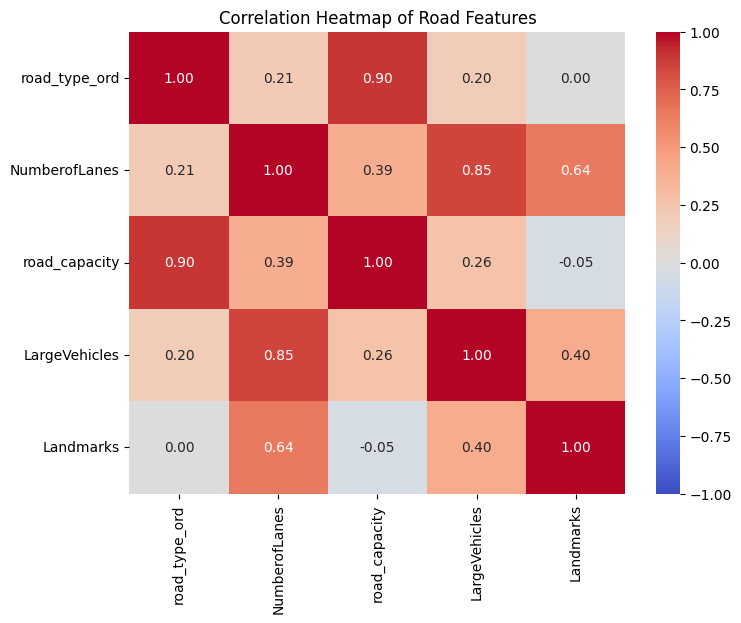

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load step07 data to access LargeVehicles and Landmarks which were dropped in step08
df_07 = pd.read_csv(os.path.join(PROC_DIR, 'train_step07.csv'))
corr_features = ['road_type_ord', 'NumberofLanes', 'road_capacity', 'LargeVehicles', 'Landmarks']
corr_matrix = df_07[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Road Features')
os.makedirs(MULTIVARIATE_PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(MULTIVARIATE_PLOTS_DIR, 'road_features_correlation.png'))
plt.show()

In [5]:
features_to_drop = extended_vif_df[extended_vif_df['VIF Score'] > 10]['Feature'].tolist()

final_confirmed_features = [f for f in FINAL_FEATURES if f not in features_to_drop]

print("Final Confirmed Feature List:")
for f in final_confirmed_features:
    print(f"- {f}")

if len(features_to_drop) == 0:
    print(f"\nAll {len(FINAL_FEATURES)} features are retained. Original FINAL_FEATURES list remains intact.")
else:
    print(f"\nFeatures dropped: {features_to_drop}")

print(f"Final feature count: {len(final_confirmed_features)}")


Final Confirmed Feature List:
- hour_sin
- is_peak_hour
- is_business_hour
- is_night
- hour_x_roadtype
- geo_hour_sin
- road_x_weather
- geo_x_roadtype
- geo_x_weather
- geo_x_peak

Features dropped: ['latitude', 'longitude', 'Temperature', 'hour', 'NumberofLanes', 'hour_squared', 'temp_squared', 'road_combo', 'weather_severity', 'road_type_ord', 'road_capacity', 'geohash_prefix_enc', 'temp_x_weather', 'hour_cos', 'lanes_x_weather', 'geohash_target_enc']
Final feature count: 10


In [6]:
save_path = os.path.join(PROC_DIR, 'vif_results.csv')
extended_vif_df.to_csv(save_path, index=False)
print(f"Extended VIF results saved to: {save_path}")


Extended VIF results saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\vif_results.csv
